In [2]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

import nengo 
import nengo_spa as spa
import sspspace

In [51]:
# Hyper parameters
LS = 2
RES_X, RES_Y = 20, 20
RNG = np.random.RandomState(42)

# Initialize SSP space - define encoding method in config (jinc, sinc, gaus)
ssp_space = sspspace.HexagonalSSPSpace(domain_dim=2, n_rotates=7, n_scales=7, length_scale=LS)
SSP_DIM = ssp_space.ssp_dim


# Create vocabulary 
CLASS_LST = ['CUP', 'BOTTLE', 'PLANT', 'MUG', 'PLATE']
vocab = spa.Vocabulary(dimensions=SSP_DIM, pointer_gen=RNG)

# Add semantic pointers for each object to the vocabulary
for i, class_name in enumerate(CLASS_LST):
    vector = vocab.algebra.create_vector(SSP_DIM, properties={"positive", "unitary"})
    vocab.add(f"{class_name.upper().replace(' ', '')}", vector)

# Generate xy coordinates
x_coords, y_coords = torch.meshgrid(torch.arange(0, RES_X), torch.arange(0, RES_Y), indexing='ij')
coords = np.stack((x_coords.flatten(), y_coords.flatten()), axis=-1)
ssp_grid = ssp_space.encode(coords)
ssp_grid = ssp_grid.reshape((RES_X, RES_Y, -1))

print(f'Generated SSP grid: {ssp_grid.shape}')

Generated SSP grid: (20, 20, 295)


In [62]:
obj_locations = {'cup': (2, 3), 'bottle': (7, 12), 'plant': (17, 6)}

# init empty environment 
global_map = sspspace.SSP(np.zeros((1, SSP_DIM)))

# encode each object at its location in the SSP representation 
for key, loc in obj_locations.items():
    print(key.upper())
    
    # get label SSP from voabulary and location SSP from grid 
    label_ssp = vocab[key.upper()].v
    
    loc_mask = np.zeros((RES_X*2, RES_Y*2))
    loc_mask[loc[1], loc[0]] = 1
    loc_ssp = ssp_grid[loc[1], loc[0]]
    
    # bind label SSP to it's location SSP 
    bound_vectors = sspspace.SSP(label_ssp[None, :]) * loc_ssp[None, :]
    assert type(bound_vectors) == sspspace.SSP
    
    # add bound vectors to the global environment SSP representation
    global_map += bound_vectors

# normalize environment ssp 
global_map = sspspace.ssp.normalize(global_map)

CUP
BOTTLE
PLANT


CUP predicted location: (2, 3)
BOTTLE predicted location: (7, 12)
PLANT predicted location: (17, 6)


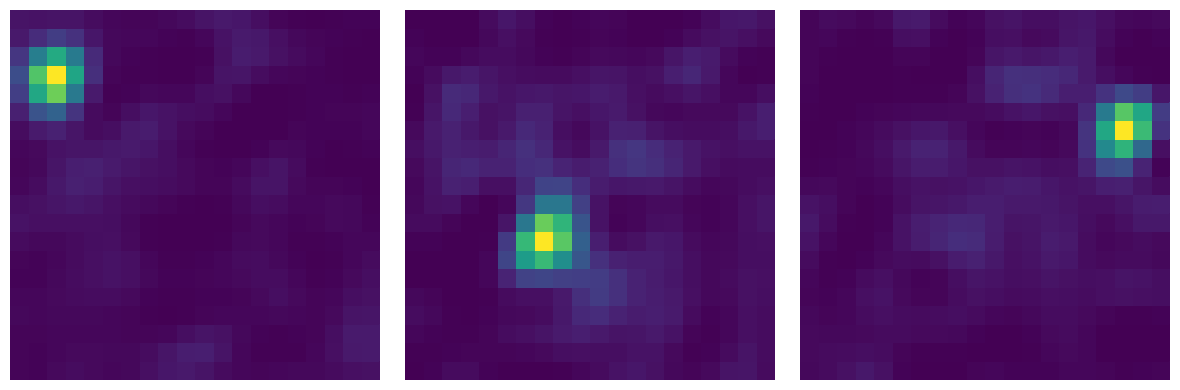

In [63]:
# plot image and segmentations 
f, axs = plt.subplots(1, 3, sharey=False, figsize=(12, 4))
all_sims = []
for i, key in enumerate(obj_locations): 
    
    # get similarity map of label with all locations by binding with inverse ssp 
    label_ssp = vocab[key.upper()].v
    out = global_map * ~sspspace.SSP(label_ssp[None, :])
    sims = out @ ssp_grid.reshape((-1, SSP_DIM)).T
    
    # decode location = point with maximum similarity to label 
    sims = sims.reshape((RES_X, RES_Y))
    sims = sims ** 2  # born's rule 
    sims = sims / np.max(sims)
    
    pred_loc = np.array(np.unravel_index(np.argmax(sims), sims.shape))
    print(f'{key.upper()} predicted location: {tuple(np.flip(pred_loc))}')
    
    axs[i].imshow(np.array(sims), cmap='viridis')
    axs[i].axis('off')
    
    all_sims.append(np.array(sims))

f.tight_layout()
plt.show()

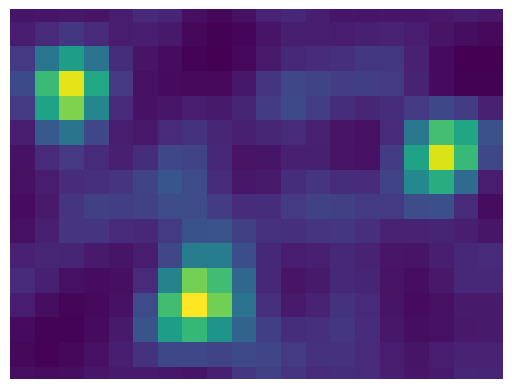

In [64]:
sims_map = np.mean(np.array(all_sims), axis=0)
plt.imshow(sims_map)
plt.axis('off')
plt.ylim(15, 0)
plt.show()